<a href="https://colab.research.google.com/github/dnoah13/cs_3120_classwork/blob/main/nhl_draft_player_data_success_willsd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NHL Draft Success Analysis

The goal of this project is to analyze NHL draft data to understand what factors influence player success.

We test the following hypotheses:

1. Draft position is negatively associated with NHL career success (measured by games played).
2. Player position group (forward, defenseman, goalie) is associated with NHL career success.
3. Draft position has a stronger influence on NHL career success than player position group.

Two definitions of success are used:
- Games Played Success: Player has played at least 200 NHL games
- Hybrid Success: Player has played at least 200 games OR played at least 50 games with ≥ 0.5 points per game

Using two definitions allows us to evaluate whether conclusions depend on how success is defined.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score
from sklearn.inspection import PartialDependenceDisplay

The dataset selected is the NHL Draft Hockey Player Data (1963-2022) from Kaggle: https://www.kaggle.com/datasets/mattop/nhl-draft-hockey-player-data-1963-2022. This dataset contains information on NHL draft picks over several decades, along with player characteristics and career outcomes. It contains over 12,200 observations (players) and 23 variables. Some of the most relevant features include:


overall_pick : player’s draft position

position : player position (e.g., Forward, Defenseman, Goalie)

games_played : total games played by player (non-goalie)

points : career performance statistics


The data from this dataset was collected from Sports Reference (https://www.sports-reference.comLinks to an external site.), and then cleaned for data analysis.

In [2]:
# Load data
df = pd.read_csv("https://raw.githubusercontent.com/dnoah13/cs_3120_classwork/273f41f2bf6337c0504386d6af0b7025ba8d5863/nhldraft.csv")
df.head()

,id,year,overall_pick,team,player,nationality,position,age,to_year,amateur_team,...,points,plus_minus,penalties_minutes,goalie_games_played,goalie_wins,goalie_losses,goalie_ties_overtime,save_percentage,goals_against_average,point_shares
0,1,2022,1,Montreal Canadiens,Juraj Slafkovsky,SK,LW,18.0,NaN,TPS (Finland),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2022,2,New Jersey Devils,Simon Nemec,SK,D,18.0,NaN,HK Nitra (Slovakia),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2022,3,Arizona Coyotes,Logan Cooley,US,C,18.0,NaN,USA U-18 Development Team (USDP/USHL),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2022,4,Seattle Kraken,Shane Wright,CA,C,18.0,NaN,Kingston Frontenacs (OHL),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2022,5,Philadelphia Flyers,Cutter Gauthier,SE,LW,18.0,NaN,USA U-18 Development Team (USDP/USHL),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


To handle missing data, we did a couple of things. For career performance statistics, such as goals, assists, and points we filled missing stats with zeroes making the assumption that a missing figure means the drafted player didn't score, assist, or record a point. Furthermore, for games_played we also filled empty values with a zero, making the assumption the drafted player did not play an NHL game.

Observations with missing position values were removed from the dataset, as they represented a very small proportion and could not be meaningfully categorized.

We also created two definitions of "success" for testing. First, we defined *success* as having played in 200 NHL games. A threshold of 200 NHL games was used to define a successful career. This cutoff was chosen because it represents sustained participation in the NHL, corresponding to approximately two to three full seasons of play. Players with fewer than 200 games often include those who had short or limited careers, while those exceeding this threshold are more likely to have established themselves as regular NHL players. Although this threshold is somewhat arbitrary, it provides a reasonable and interpretable way to distinguish between short-term participation and longer-term career success. To address potential limitations of this definition, particularly for players with shorter but highly productive careers, a second “hybrid” definition of success was also used. This incorporates both career length and scoring efficiency. Although this threshold is somewhat arbitrary, it is supported by the distribution of the data (first plot of the EDA) and provides a reasonable way to distinguish between short and long careers.

Finally, the original position variable contained many detailed and sometimes inconsistent labels (e.g., LW, RW, C, LW/RW, F, W). To simplify analysis and improve interpretability, these were grouped into three broader categories: Forward, Defenseman, and Goalie. Players labeled as C (center), LW (left wing), RW (right wing), F (forward), or W (wing) were classified as forwards. Players labeled as D were classified as defensemen, and players labeled as G were classified as goalies. This grouping reduces noise from multiple or overlapping position labels and reflects the primary roles players occupy on the ice. It also allows for clearer comparisons and more stable model performance.

In [3]:
nhl = df.copy()

# Fill missing career stats
for col in ["games_played", "goals", "assists", "points"]:
    nhl[col] = nhl[col].fillna(0)

# Points per game
nhl["ppg"] = nhl["points"] / nhl["games_played"]
nhl["ppg"] = nhl["ppg"].replace([np.inf, -np.inf], 0).fillna(0)

# Success definitions
nhl["success_gp"] = (nhl["games_played"] >= 200).astype(int)

nhl["success_hybrid"] = np.where(
    (nhl["games_played"] >= 200) |
    ((nhl["games_played"] >= 50) & (nhl["ppg"] >= 0.5)),
    1, 0
)

# Position grouping
nhl["position_group"] = nhl["position"].apply(
    lambda x: "Forward" if any(p in str(x) for p in ["C","LW","RW","F","W"])
    else ("Defenseman" if "D" in str(x) else ("Goalie" if "G" in str(x) else "Unknown"))
)

# Drops observations with unknown positions
nhl = nhl[nhl["position_group"] != "Unknown"]

## Exploratory Data Analysis

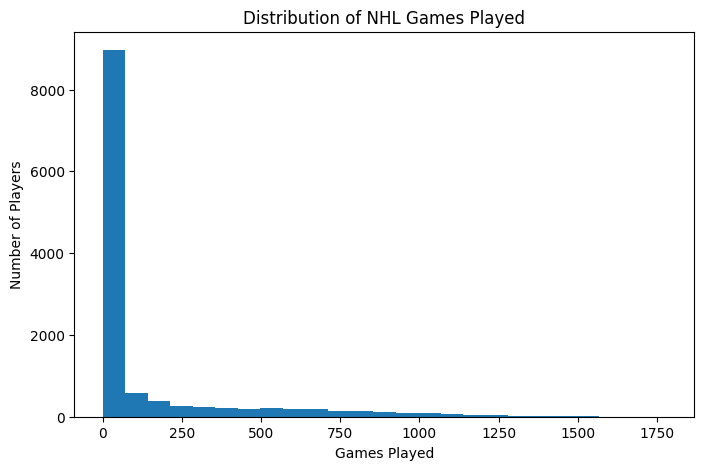

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(nhl["games_played"], bins=25)
plt.title("Distribution of NHL Games Played")
plt.xlabel("Games Played")
plt.ylabel("Number of Players")
plt.show()

The distribution of NHL games played is highly right-skewed, with a large number of players having very few games and a smaller number having long careers. A threshold of 200 games was chosen to define a successful career, as it represents a clear separation between short-term participation and sustained NHL involvement.

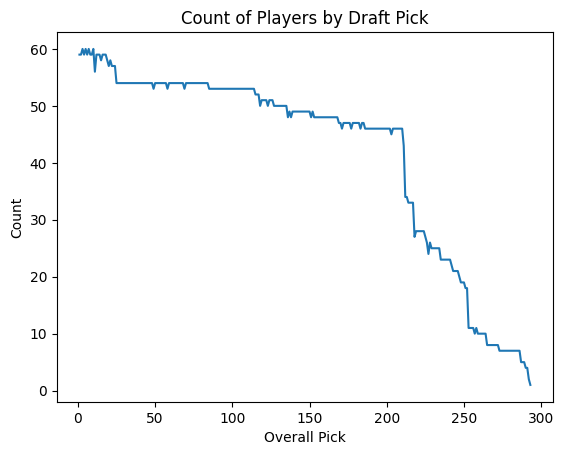

In [5]:
# Distribution of draft picks
nhl["overall_pick"].value_counts().sort_index().plot()
plt.title("Count of Players by Draft Pick")
plt.xlabel("Overall Pick")
plt.ylabel("Count")
plt.show()

The distribution of draft positions appears uneven due to changes in the number of teams and draft rounds over time. Earlier picks are consistently represented across all draft years, while later picks occur only in more recent drafts, leading to fewer observations and a more irregular distribution.

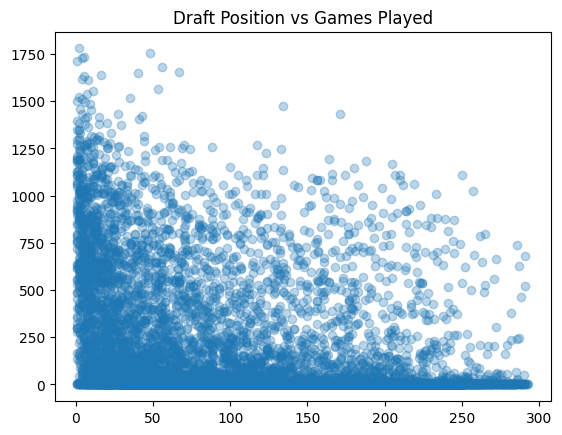

In [6]:
# Draft position vs games played
plt.scatter(nhl["overall_pick"], nhl["games_played"], alpha=0.3)
plt.title("Draft Position vs Games Played")
plt.show()

There is a visible downward trend, suggesting that players drafted later tend to play fewer NHL games.

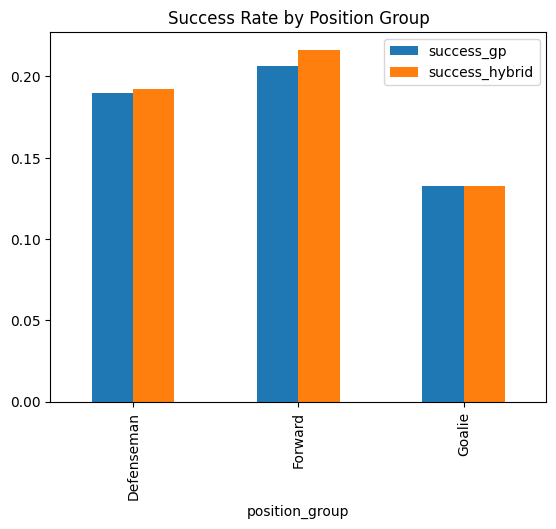

,count
position_group,
Forward,7040
Defenseman,3966
Goalie,1217


In [7]:
# Success by position group
nhl.groupby("position_group")[["success_gp","success_hybrid"]].mean().plot(kind="bar")
plt.title("Success Rate by Position Group")
plt.show()

# Display a count of each position group
nhl["position_group"].value_counts()

Success rates differ across position groups, suggesting that player role may influence career outcomes.

## Regression Analysis: Draft Position vs Career Success

In [8]:
# Regression analysis
X_reg = nhl[["overall_pick"]]
y_reg = nhl["games_played"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("R²:", r2_score(y_test, pred))

Coefficient: -1.3277820518514658
R²: 0.12616968213428992


The regression coefficient is negative (-1.33), indicating that as draft position increases (i.e., players are drafted later), the number of NHL games played tends to decrease. Specifically, each one-pick increase in draft position is associated with approximately 1.33 fewer games played on average.

The R² value of approximately 0.126 indicates that draft position explains about 12.6% of the variation in career games played. While draft position is clearly related to success, this relatively low R² suggests that many other factors also influence NHL career outcomes.

Overall, these results support the hypothesis that draft position is negatively associated with NHL career success. Players drafted earlier tend to have longer careers on average. However, the relatively low R² value suggests that draft position alone is not a strong predictor of success, and that other variables are also important in determining career outcomes.

In [9]:
# Prepare data for classification
data = nhl[["overall_pick","position_group","success_gp","success_hybrid"]].copy()

data = pd.get_dummies(data, columns=["position_group"], drop_first=True)

X = data.drop(columns=["success_gp","success_hybrid"])
y_gp = data["success_gp"]
y_hybrid = data["success_hybrid"]

X_train, X_test, y_gp_train, y_gp_test, y_hybrid_train, y_hybrid_test = train_test_split(
    X, y_gp, y_hybrid, test_size=0.25, random_state=42
)

## Comparing Feature Influence

A random forest classifier was used because it can capture nonlinear relationships between draft position and career success, which are evident in the data. Unlike linear models, random forests do not assume a simple linear relationship and can model complex patterns such as the sharp decline in success probability among early draft picks.

Additionally, random forests provide measures of feature importance, which are useful for comparing the relative influence of draft position and player position group. This makes them well-suited for testing the hypotheses in this analysis.

Logistic regression was also considered as a baseline model due to its interpretability, but random forest models were preferred for their ability to capture nonlinear relationships and provide more accurate predictions.

In [10]:
# Model A - Draft position (Games played)
X_A = X[["overall_pick"]]

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_gp, test_size=0.25, random_state=42)

rf_A = RandomForestClassifier()
rf_A.fit(X_train_A, y_train_A)

pred_A = rf_A.predict(X_test_A)

print("Model A Accuracy:", accuracy_score(y_test_A, pred_A))

Model A Accuracy: 0.8304973821989529


In [11]:
# Model B - Position group (Games played)
pos_cols = [col for col in X.columns if "position_group" in col]

X_B = X[pos_cols]

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_gp, test_size=0.25, random_state=42)

rf_B = RandomForestClassifier()
rf_B.fit(X_train_B, y_train_B)

pred_B = rf_B.predict(X_test_B)

print("Model B Accuracy:", accuracy_score(y_test_B, pred_B))

Model B Accuracy: 0.8013743455497382


In [12]:
# Model C - Both (Games played)
rf_C = RandomForestClassifier()
rf_C.fit(X_train, y_gp_train)

pred_C = rf_C.predict(X_test)

print("Model C Accuracy:", accuracy_score(y_gp_test, pred_C))

Model C Accuracy: 0.8219895287958116


In [13]:
# Model A - Draft position (Games played + PPG)
X_A = X[["overall_pick"]]

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_hybrid, test_size=0.25, random_state=42)

rf_A = RandomForestClassifier()
rf_A.fit(X_train_A, y_train_A)

pred_A = rf_A.predict(X_test_A)

print("Model A Accuracy:", accuracy_score(y_test_A, pred_A))

Model A Accuracy: 0.8295157068062827


In [14]:
# Model B - Position group (Games played + PPG)
pos_cols = [col for col in X.columns if "position_group" in col]

X_B = X[pos_cols]

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_hybrid, test_size=0.25, random_state=42)

rf_B = RandomForestClassifier()
rf_B.fit(X_train_B, y_train_B)

pred_B = rf_B.predict(X_test_B)

print("Model B Accuracy:", accuracy_score(y_test_B, pred_B))

Model B Accuracy: 0.7961387434554974


In [15]:
# Model C - Both (Games played + PPG)
rf_C = RandomForestClassifier()
rf_C.fit(X_train, y_hybrid_train)

pred_C = rf_C.predict(X_test)

print("Model C Accuracy:", accuracy_score(y_hybrid_test, pred_C))

Model C Accuracy: 0.819371727748691


In [16]:
# Create a results table
results = pd.DataFrame({
    "Model": ["Model A (Draft Position Only)", "Model B (Position Group Only)", "Model C (Both)"],

    "Accuracy (Games Played)": [
        0.8304973821989529,
        0.8013743455497382,
        0.81937172774869
    ],

    "Accuracy (Games Played + PPG)": [
        0.8295157068062827,
        0.7961387434554974,
        0.8167539267015707
    ]
})

# Round for readability
results = results.round(3)

results

,Model,Accuracy (Games Played),Accuracy (Games Played + PPG)
0,Model A (Draft Position Only),0.830,0.830
1,Model B (Position Group Only),0.801,0.796
2,Model C (Both),0.819,0.817


The model comparison results show that draft position is a stronger predictor of NHL career success than player position group.

For both definitions of success, the model using draft position alone achieved the highest accuracy (approximately 0.83), while the model using position group alone performed worse (approximately 0.80).

The table above compares model performance across different feature sets and definitions of success. Models using draft position alone achieved the highest accuracy, while models using position group alone performed worse. Including both features did not improve accuracy, suggesting that draft position is the dominant predictor.

NOTE: The model using only position group predicts the probability of success based on whether a player is a forward, defenseman, or goalie. Position group is encoded using dummy variables, with defensemen serving as the reference category. The model therefore learns how forwards and goalies differ from defensemen in terms of success probability. Although some differences exist between position groups, the model’s lower accuracy suggests that position alone is not a strong predictor of NHL success.

overall_pick              0.986922
position_group_Goalie     0.006917
position_group_Forward    0.006161
dtype: float64


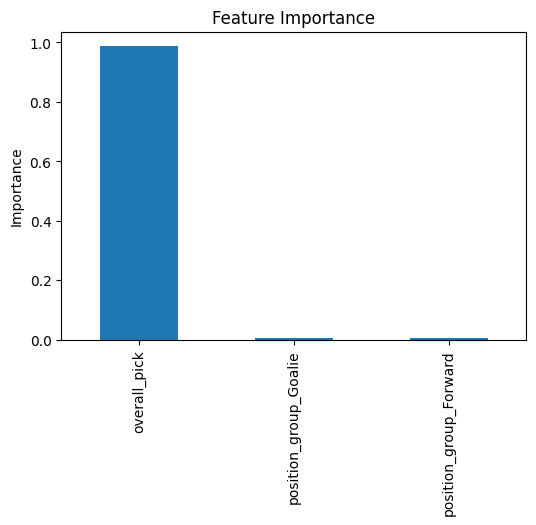

In [17]:
importance = pd.Series(rf_C.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

importance.plot(kind="bar", figsize=(6,4))
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

Feature importance results from the random forest model show that draft position is by far the most influential predictor of NHL career success. The variable `overall_pick` accounts for approximately 98.8% of the total feature importance, while position group variables each contribute less than 1%.

Although exploratory analysis suggested some differences in success rates across position groups, the models indicate that these differences are minimal compared to the effect of draft position.

The feature importance results show that draft position is the dominant factor in predicting NHL success, while position group contributes very little additional information.

NOTE: When encoding position group, one category (Defenseman) was used as the reference group and not explicitly included in the model. The remaining variables (Forward and Goalie) are interpreted relative to this baseline.

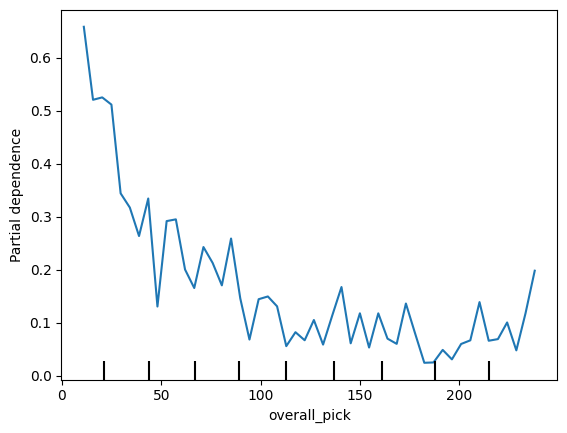

In [18]:
PartialDependenceDisplay.from_estimator(
    rf_C,
    X_train,
    ["overall_pick"],
    kind="average",
    grid_resolution=50
)

The partial dependence plot shows a strong negative relationship between draft position and the probability of NHL success. Players selected early in the draft (especially within the first 30 picks) have a much higher probability of success.

As draft position increases, the probability of success declines sharply, particularly within the first 100 picks. Beyond this range, the relationship becomes relatively flat, indicating that later draft picks generally have low and similar probabilities of success.

Some variability is observed at higher pick numbers, likely due to smaller sample sizes and increased randomness in later rounds.

## Conclusions and Implications

This analysis examined how draft position and player position group relate to NHL career success.

The regression results showed that draft position is negatively associated with career success, as later draft picks tend to play fewer games. However, the R² value of approximately 0.126 indicates that draft position alone explains only a small portion of the variation in career outcomes.

The classification models further demonstrated that draft position is a stronger predictor of success than player position group. Models using draft position alone consistently outperformed those using position group alone.

Interestingly, adding position group to the model did not improve performance and slightly reduced accuracy. This suggests that position group does not provide meaningful additional predictive value beyond draft position.

Feature importance results strongly support this conclusion, showing that draft position accounts for nearly all of the model’s predictive power, while position group contributes very little.

The partial dependence plot confirms that success probability decreases sharply after early draft picks and remains low for later selections.

Overall, these results indicate that draft position is the dominant factor in predicting NHL success, while position group plays a relatively minor role.